In [2]:
import pandas as pd
import plotly.express as px
from datetime import datetime
import pytz

In [35]:
play = pd.read_csv("Play Store Data.csv")
reviews = pd.read_csv("User Reviews.csv")

In [40]:
print(play.info())
print(play.isnull().sum())
play.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [42]:
play = play.drop_duplicates(subset="App")

In [45]:
play["Rating"] = pd.to_numeric(
    play["Rating"],
    errors="coerce"
)
play["Rating"].describe()

count    8197.000000
mean        4.175052
std         0.561026
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [ ]:
play["Reviews"] = pd.to_numeric(
    play["Reviews"],
    errors="coerce"
)

In [51]:
play["Installs"].unique()[:10]
play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

play["Installs"] = pd.to_numeric(
    play["Installs"],
    errors="coerce"
)
print(play["Installs"])
play["Installs"].dtype
play["Installs"].head()

0           10000.0
1          500000.0
2         5000000.0
3        50000000.0
4          100000.0
            ...    
10836        5000.0
10837         100.0
10838        1000.0
10839        1000.0
10840    10000000.0
Name: Installs, Length: 9660, dtype: float64


0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [59]:
play["Size"].unique()[:20]
def convert_size(size):

    if pd.isna(size):
        return None

    size = str(size)

    if size.endswith("M"):
        return float(size[:-1])

    elif size.endswith("k"):
        return float(size[:-1]) / 1024

    else:
        return None
play["Size_MB"] = play["Size"].apply(convert_size)
print(play["Size_MB"])

0        19.0
1        14.0
2         8.7
3        25.0
4         2.8
         ... 
10836    53.0
10837     3.6
10838     9.5
10839     NaN
10840    19.0
Name: Size_MB, Length: 9660, dtype: float64


In [60]:
play.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             1
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
Size_MB           1228
dtype: int64

In [67]:
reviews.isnull().sum
reviews = reviews.dropna(
    subset=["App"]
)
reviews["Sentiment_Subjectivity"] = pd.to_numeric(
    reviews["Sentiment_Subjectivity"],
    errors="coerce"
)
subjectivity = (
    reviews
    .groupby("App")["Sentiment_Subjectivity"]
    .mean()
    .reset_index()
)
subjectivity.head()

,App,Sentiment_Subjectivity
0,10 Best Foods for You,0.495455
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.545516
2,11st,0.443957
3,1800 Contacts - Lens Store,0.591098
4,1LINE – One Line with One Touch,0.557315


In [70]:
df = play.merge(
    subjectivity,
    on="App",
    how="left"
)
print(df.info())
print(df.shape)
print(df.head())
df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce"
)
df["Reviews"].dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     9660 non-null   object 
 1   Category                9660 non-null   object 
 2   Rating                  8197 non-null   float64
 3   Reviews                 9660 non-null   object 
 4   Size                    9660 non-null   object 
 5   Installs                9659 non-null   float64
 6   Type                    9659 non-null   object 
 7   Price                   9660 non-null   object 
 8   Content Rating          9659 non-null   object 
 9   Genres                  9660 non-null   object 
 10  Last Updated            9660 non-null   object 
 11  Current Ver             9652 non-null   object 
 12  Android Ver             9657 non-null   object 
 13  Size_MB                 8432 non-null   float64
 14  Sentiment_Subjectivity  816 non-null    

dtype('float64')

In [73]:
categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENTS"
]

filtered_df = df[
    df["Category"].isin(categories)
]
filtered_df.shape

(2379, 15)

In [76]:
filtered_df = filtered_df[
    (filtered_df["Rating"] > 3.5) &
    (filtered_df["Reviews"] > 500) &
    (filtered_df["Installs"] > 50000) &
    (filtered_df["Sentiment_Subjectivity"] > 0.5)
]
filtered_df = filtered_df[
    ~filtered_df["App"].str.contains(
        "s",
        case=False,
        na=False
    )
]
filtered_df.shape

(29, 15)

In [81]:
filtered_df["Category"] = (
    filtered_df["Category"]
    .replace({
        "BEAUTY": "सौंदर्य",
        "BUSINESS": "வணிகம்",
        "DATING": "Partnersuche"
    })
)
filtered_df.shape

(29, 15)

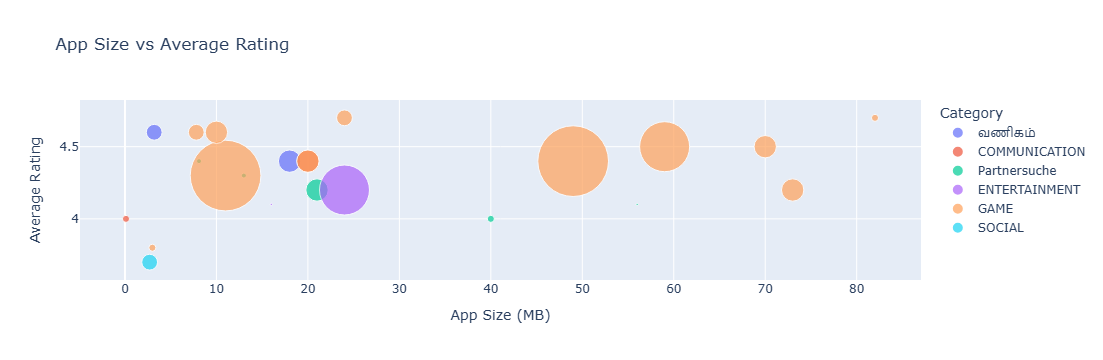

In [79]:
import plotly.express as px

fig = px.scatter(
    filtered_df,
    x="Size_MB",
    y="Rating",
    size="Installs",
    color="Category",
    hover_name="App",
    title="App Size vs Average Rating",
    labels={
        "Size_MB": "App Size (MB)",
        "Rating": "Average Rating"
    },
    size_max=50
)

fig.show()

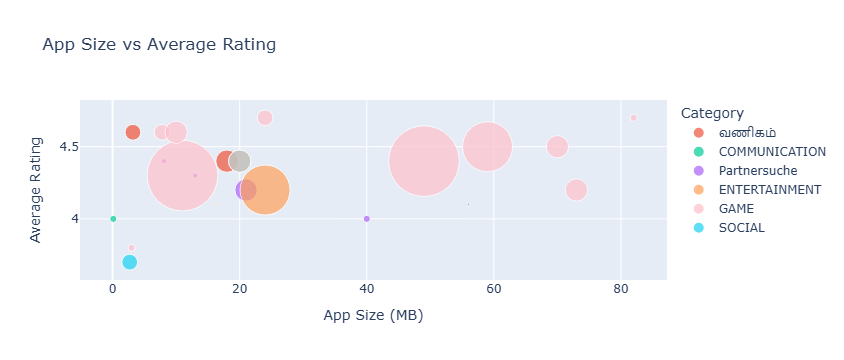

In [80]:
fig = px.scatter(
    filtered_df,
    x="Size_MB",
    y="Rating",
    size="Installs",
    color="Category",
    hover_name="App",
    title="App Size vs Average Rating",
    labels={
        "Size_MB": "App Size (MB)",
        "Rating": "Average Rating"
    },
    size_max=50,
    color_discrete_map={
        "GAME": "pink"
    }
)

fig.show()

In [90]:
from datetime import datetime
import pytz

india = pytz.timezone("Asia/Kolkata")
now = datetime.now(india)

if 17 <= now.hour < 19:
    fig.show()
else:
    print(
        "Bubble chart is available only between 5 PM and 7 PM IST."
    )

Bubble chart is available only between 5 PM and 7 PM IST.


In [88]:
fig.write_html(
    "bubble_chart_dashboard.html"
)